In [2]:
from dotenv import load_dotenv
from typing import TypedDict
from gen_ai_hub.proxy.langchain.openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END


In [3]:
load_dotenv()

True

In [5]:
#create model
model=ChatOpenAI(proxy_model_name='gpt-4o')

In [6]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str

In [7]:
def create_outline(state:BlogState)->BlogState:
    #title fetch
    title=state["title"]
    prompt=f"Generate a detail outline for a blog on the topic-{title}"
    outline=model.invoke(prompt).content
    #update state
    state["outline"]=outline
    return state

In [8]:
def create_blog(state:BlogState)->BlogState:
    title=state["title"]
    outline=state["outline"]
    prompt=f"Write a detailed blog on the title - {title} using the follwing outline \n {outline}"
    content=model.invoke(prompt).content
    #update state
    state["content"]=content
    return state

In [15]:
graph=StateGraph(BlogState)
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

Workflow= graph.compile()

In [16]:
#execute
initial_state={'title':'Rise of AI in India'}
final_state= Workflow.invoke(initial_state)
print(final_state)

{'title': 'Rise of AI in India', 'outline': "Title: The Rise of AI in India: Revolutionizing Industries and Empowering Citizens\n\n**Introduction**\n- Brief overview of AI technology and its global prominence\n- Importance of AI's growth in developing economies like India\n- Thesis statement: The rise of AI in India is reshaping industries, enhancing government efficiency, and empowering citizens.\n\n**I. Understanding the Landscape of AI in India**\nA. Historical context and initial adoption of AI technologies\n   1. Early developments in Indian academia and research\n   2. Government initiatives and policy frameworks\nB. Current state of AI in India\n   1. Major sectors adopting AI technologies\n   2. Key players and stakeholders in the AI ecosystem\n\n**II. Infrastructure and Policy Support**\nA. Government efforts to promote AI\n   1. National AI Policies and schemes\n   2. Collaborations with global AI leaders\nB. Investment in AI research and infrastructure\n   1. Establishment o

In [18]:
print(final_state["outline"])

Title: The Rise of AI in India: Revolutionizing Industries and Empowering Citizens

**Introduction**
- Brief overview of AI technology and its global prominence
- Importance of AI's growth in developing economies like India
- Thesis statement: The rise of AI in India is reshaping industries, enhancing government efficiency, and empowering citizens.

**I. Understanding the Landscape of AI in India**
A. Historical context and initial adoption of AI technologies
   1. Early developments in Indian academia and research
   2. Government initiatives and policy frameworks
B. Current state of AI in India
   1. Major sectors adopting AI technologies
   2. Key players and stakeholders in the AI ecosystem

**II. Infrastructure and Policy Support**
A. Government efforts to promote AI
   1. National AI Policies and schemes
   2. Collaborations with global AI leaders
B. Investment in AI research and infrastructure
   1. Establishment of AI think tanks and research centers
   2. Funding and incentivi

In [19]:
print(final_state["content"])

# The Rise of AI in India: Revolutionizing Industries and Empowering Citizens

## Introduction

Artificial Intelligence (AI) is a transformative technology redefining how we live, work, and interact with the world. Its global prominence has surged over the last decade, finding applications in diverse sectors such as healthcare, agriculture, finance, and governance. AI's growth in developing economies like India is crucial, as it holds the promise of alleviating structural weaknesses and fostering inclusive development. The rise of AI in India is reshaping industries, enhancing government efficiency, and empowering citizens, paving the way for a technologically advanced society.

## I. Understanding the Landscape of AI in India

### A. Historical Context and Initial Adoption of AI Technologies

India's foray into AI began in academia and research institutions, with early developments focused on theoretical foundations and algorithmic innovations. Esteemed institutions like IITs (Indian 

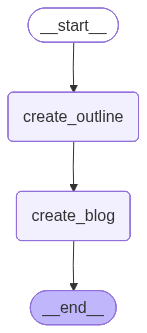

In [20]:
from IPython.display import Image
Image(Workflow.get_graph().draw_mermaid_png())